In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
## Data Gathering
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
## Exploratory Data Analysis (EDA) using .shape[0,1,2] and plt.imshow

# Number of pictures and dimensions for each
print(f' Number of pictues: {x_train.shape[0]} \n Dimensions: {x_train.shape[1]} x {x_train.shape[2]}')

 Number of pictues: 60000 
 Dimensions: 28 x 28


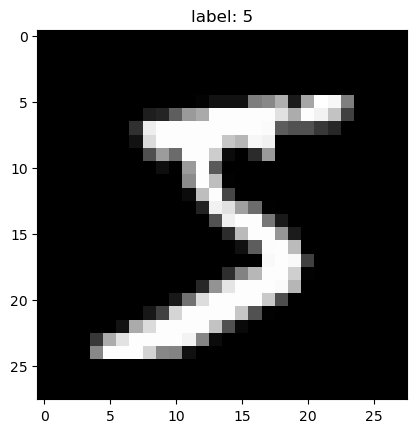

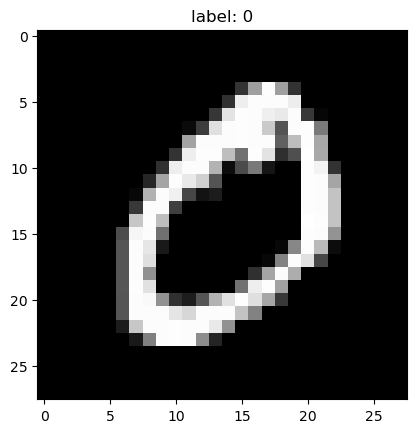

In [5]:
for image in range(2):
    plt.imshow(x_train[image], cmap = 'gray')
    plt.title(f'label: {y_train[image]}')
    plt.show()

In [6]:
## Data preprocessing

# Normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [7]:
# Fixing color = Gray
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [8]:
x_train.shape

(60000, 28, 28, 1)

In [9]:
## Model building 
# Seqeuential data structure to hold NN layers
# CNN with 32 filters , 3x3 filter size each
# CNN with 64 filters , 3x3 filter size each # no need to tell the model the input shape here too , once is enough
# MaxPooling to reduce pictures size by 2
# Softmax activation function instead of sigmoid to handle multiple probabilites not just 0\1

model = models.Sequential()
model.add(layers.Input(shape=(28, 28, 1)))

model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2))) 

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu')) 
model.add(layers.Dense(10, activation='softmax')) 

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
## Model Training & Evaluation
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

print("Model Training...")
history = model.fit(x_train, y_train, 
                    epochs=5, 
                    batch_size=64, 
                    validation_data=(x_test, y_test))

Model Training...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9437 - loss: 0.1904 - val_accuracy: 0.9815 - val_loss: 0.0615
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.9836 - loss: 0.0542 - val_accuracy: 0.9851 - val_loss: 0.0438
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9879 - loss: 0.0386 - val_accuracy: 0.9866 - val_loss: 0.0428
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9909 - loss: 0.0293 - val_accuracy: 0.9889 - val_loss: 0.0350
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.9930 - loss: 0.0218 - val_accuracy: 0.9893 - val_loss: 0.0295


In [11]:
model.save('handwriting_model.keras')

In [ ]:
!pip install ipycanvas ipywidgets pillow

In [13]:
import gradio as gr
import tensorflow as tf
import numpy as np
import cv2

model = tf.keras.models.load_model('handwriting_model.keras', compile=False)
def classify_digit(img_data):
    if img_data is None:
        return {str(i): 0.0 for i in range(10)}

    if isinstance(img_data, dict):
        img = img_data['composite']
    else:
        img = img_data

    if len(img.shape) == 3 and img.shape[2] == 4: # RGBA
        gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
    elif len(img.shape) == 3 and img.shape[2] == 3: # RGB
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img 

    inverted = cv2.bitwise_not(gray)
    resized = cv2.resize(inverted, (28, 28))
    normalized = resized / 255.0
    reshaped = normalized.reshape(1, 28, 28, 1)
    prediction = model.predict(reshaped, verbose=0)
    return {str(i): float(prediction[0][i]) for i in range(10)}

interface = gr.Interface(
    fn=classify_digit,
    inputs=gr.Sketchpad(), 
    outputs=gr.Label(num_top_classes=3),
    title="Handwritten Digit Recognizer",
    description="Draw a single digit (0-9) in the box to test the CNN model."
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7862

Could not create share link. Missing file: C:\Users\abdu1\.cache\huggingface\gradio\frpc\frpc_windows_arm64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_arm64.exe
2. Rename the downloaded file to: frpc_windows_arm64_v0.3
3. Move the file to this location: C:\Users\abdu1\.cache\huggingface\gradio\frpc
